In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import math
import random

### Question#1

In [ ]:
#Tic Tac Toe Player

X = "X"
O = "O"
D = "D"
EMPTY = None


def initial_state():
    """
    Returns starting state of the board.
    """
    return [[EMPTY, EMPTY, EMPTY],
            [EMPTY, EMPTY, EMPTY],
            [EMPTY, EMPTY, EMPTY]]


def player(board):
    """
    Returns player who has the next turn on a board.
    """
    count = 0
    for i in board:
        for j in i:
            if j:
                count += 1
    if count % 2 != 0:
        return O
    return X


def actions(board):
    """
    Returns set of all possible actions (i, j) available on the board.
    """
    res = set()
    board_len = len(board)
    for i in range(board_len):
        for j in range(board_len):
            if board[i][j] == EMPTY:
                res.add((i, j))
    return res


def result(board, action):
    """
    Returns the board that results from making move (i, j) on the board.
    """
    curr_player = player(board)
    result_board = copy.deepcopy(board)
    (i, j) = action
    result_board[i][j] = curr_player
    return result_board


def get_horizontal_winner(board):
    # check horizontally
    winner_val = None
    board_len = len(board)
    for i in range(board_len):
        winner_val = board[i][0]
        for j in range(board_len):
            if board[i][j] != winner_val:
                winner_val = None
        if winner_val:
            return winner_val
    return winner_val


def get_vertical_winner(board):
    # check vertically
    winner_val = None
    board_len = len(board)
    for i in range(board_len):
        winner_val = board[0][i]
        for j in range(board_len):
            if board[j][i] != winner_val:
                winner_val = None
        if winner_val:
            return winner_val
    return winner_val


def get_diagonal_winner(board):
    # check diagonally
    winner_val = None
    board_len = len(board)
    winner_val = board[0][0]
    for i in range(board_len):
        if board[i][i] != winner_val:
            winner_val = None
    if winner_val:
        return winner_val

    winner_val = board[0][board_len - 1]
    for i in range(board_len):
        j = board_len - 1 - i
        if board[i][j] != winner_val:
            winner_val = None

    return winner_val


def winner(board):
    """
    Returns the winner of the game, if there is one.
    """
    winner_val = get_horizontal_winner(board) or get_vertical_winner(board) or get_diagonal_winner(board) or None
    return winner_val


def terminal(board):
    """
    Returns True if game is over, False otherwise.
    """
    if winner(board) != None:
        return True

    for i in board:
        for j in i:
            if j == EMPTY:
                return False
    return True

def utility(board):
    """
    Returns 1 if X has won the game, -1 if O has won, 0 otherwise.
    """
    winner_val = winner(board)
    if winner_val == X:
        return 1
    elif winner_val == O:
        return -1
    return 0


def minimax(board):
    """
    Compute the optimal action for the current player on the board.
    """
    
    def min_value(board):
        if terminal(board):
            return utility(board)
        v = float('inf')
        for action in actions(board):
            v = min(v, max_value(result(board, action)))
        return v

    def max_value(board):
        if terminal(board):
            return utility(board)
        v = float('-inf')
        for action in actions(board):
            v = max(v, min_value(result(board, action)))
        return v

    current_player = player(board)

    if current_player == X:
        best_value = float('-inf')
        best_action = None
        for action in actions(board):
            val = min_value(result(board, action))
            if val > best_value:
                best_value = val
                best_action = action
        return best_action
    else:
        best_value = float('inf')
        best_action = None
        for action in actions(board):
            val = max_value(result(board, action))
            if val < best_value:
                best_value = val
                best_action = action
        return best_action

In [5]:
if __name__ == "__main__":
    user = None
    board = initial_state()
    ai_turn = False
    print("Choose a player")
    user=input()
    while True:
        game_over =terminal(board)
        print(game_over)
        playr = player(board)
        print(playr,user)
        if game_over:
            winner = winner(board)
            if winner is None:
                print("Game Over: Tie.")
            else:
                print(f"Game Over: {winner} wins.")
            break

        else:

            if user != playr and not game_over:
                 if ai_turn:
                        possible_moves = list(actions(board))
                        if possible_moves:
                            move = random.choice(possible_moves)
                        else:
                            print("No possible moves for AI, game should be over.")
                            break

                        board = result(board,( move[0], move[1]))
                        ai_turn = False
                        print(board)


            elif user == playr and not game_over:
                ai_turn = True
                while True:
                    print("Enter the position to move (row,col)")
                    try:
                        i=int(input("Row:"))
                        j=int(input("Col:"))
                        if 0 <= i < 3 and 0 <= j < 3:
                            if board[i][j] == EMPTY:
                                board = result(board, (i, j))
                                print(board)
                                break
                            else:
                                print("That cell is already taken. Please choose an empty cell.")
                        else:
                            print("Invalid input. Row and column must be between 0 and 2.")
                    except ValueError:
                        print("Invalid input. Please enter numbers for row and column.")

Choose a player
False
X X
Enter the position to move (row,col)
[[None, None, None], ['X', None, None], [None, None, None]]
False
O X
[[None, None, None], ['X', None, None], [None, None, 'O']]
False
X X
Enter the position to move (row,col)
[[None, 'X', None], ['X', None, None], [None, None, 'O']]
False
O X
[[None, 'X', None], ['X', 'O', None], [None, None, 'O']]
False
X X
Enter the position to move (row,col)
That cell is already taken. Please choose an empty cell.
Enter the position to move (row,col)
That cell is already taken. Please choose an empty cell.
Enter the position to move (row,col)
That cell is already taken. Please choose an empty cell.
Enter the position to move (row,col)
[[None, 'X', None], ['X', 'O', None], [None, 'X', 'O']]
False
O X
[[None, 'X', None], ['X', 'O', None], ['O', 'X', 'O']]
False
X X
Enter the position to move (row,col)
Invalid input. Row and column must be between 0 and 2.
Enter the position to move (row,col)
That cell is already taken. Please choose an em

### Question#2

In [57]:
Dlist=[10, 20, 30, 40, 50]
Slist=pd.Series(Dlist)
print(Slist)


0    10
1    20
2    30
3    40
4    50
dtype: int64


### Question#3

In [58]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'City': ['Lahore', 'Karachi', 'Lahore']
}
df = pd.DataFrame(data)
print(df)


      Name  Age     City
0    Alice   25   Lahore
1      Bob   30  Karachi
2  Charlie   35   Lahore


In [59]:
df.head()

,Name,Age,City
0,Alice,25,Lahore
1,Bob,30,Karachi
2,Charlie,35,Lahore


In [60]:
df.tail()

,Name,Age,City
0,Alice,25,Lahore
1,Bob,30,Karachi
2,Charlie,35,Lahore


In [61]:
print("Shape:", df.shape)  
print("Rows:", df.shape[0], "Columns:", df.shape[1])

Shape: (3, 3)
Rows: 3 Columns: 3


In [62]:
print("Data types:")
print(df.dtypes)

Data types:
Name    object
Age      int64
City    object
dtype: object


In [63]:
print("Bob's row:")
print(df[df['Name'] == 'Bob'])

Bob's row:
  Name  Age     City
1  Bob   30  Karachi


In [64]:
print("2nd row, 3rd column (iloc):")
print(df.iloc[1, 2])  

2nd row, 3rd column (iloc):
Karachi


In [65]:
print("Age > 28:")
temp_df= df[df['Age'] > 28]
print(temp_df)

Age > 28:
      Name  Age     City
1      Bob   30  Karachi
2  Charlie   35   Lahore


In [66]:
df['Score'] = [85, 90, 95]
print("After adding Score column:")
print(df)

After adding Score column:
      Name  Age     City  Score
0    Alice   25   Lahore     85
1      Bob   30  Karachi     90
2  Charlie   35   Lahore     95


In [67]:
df.loc[df['Name'] == 'Charlie', 'City'] = 'Multan'
print("After changing Charlie's city:")
print(df)

After changing Charlie's city:
      Name  Age     City  Score
0    Alice   25   Lahore     85
1      Bob   30  Karachi     90
2  Charlie   35   Multan     95


In [68]:
df.drop(df[['Score']], axis=1, inplace=True) 
print("After deleting Score column:")
print(df)

After deleting Score column:
      Name  Age     City
0    Alice   25   Lahore
1      Bob   30  Karachi
2  Charlie   35   Multan


In [69]:
print("Unique cities:", df['City'].nunique())

Unique cities: 3


In [70]:
df.describe()

,Age
count,3.0
mean,30.0
std,5.0
min,25.0
25%,27.5
50%,30.0
75%,32.5
max,35.0


### Question#4

In [71]:
file = pd.read_csv('diabetes.csv')
df = pd.DataFrame(file)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,183,0,0,0,28.4,0.212,36,1
1,5,162,104,0,0,37.7,0.151,52,1
2,2,197,70,99,0,34.7,0.575,62,1
3,13,158,114,0,0,42.3,0.257,44,1
4,0,162,76,56,100,53.2,0.759,25,1


In [72]:
print("Shape:", df.shape)

Shape: (508, 9)


In [73]:
print("Column names:", df.columns)

Column names: Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [74]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            4      183              0              0        0  28.4   
1            5      162            104              0        0  37.7   
2            2      197             70             99        0  34.7   
3           13      158            114              0        0  42.3   
4            0      162             76             56      100  53.2   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.212   36        1  
1                     0.151   52        1  
2                     0.575   62        1  
3                     0.257   44        1  
4                     0.759   25        1  


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               508 non-null    int64  
 1   Glucose                   508 non-null    int64  
 2   BloodPressure             508 non-null    int64  
 3   SkinThickness             508 non-null    int64  
 4   Insulin                   508 non-null    int64  
 5   BMI                       508 non-null    float64
 6   DiabetesPedigreeFunction  508 non-null    float64
 7   Age                       508 non-null    int64  
 8   Outcome                   508 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 35.8 KB


In [76]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000
mean,3.913386,120.911417,68.474409,19.566929,80.232283,31.764173,0.460567,33.346457,0.344488
std,3.305064,31.786424,20.436203,16.275653,119.686281,8.072185,0.322653,11.768060,0.475670
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,62.000000,0.000000,0.000000,26.600000,0.248000,24.000000,0.000000
50%,3.000000,117.000000,71.000000,22.000000,0.000000,32.000000,0.375000,29.000000,0.000000
75%,6.000000,140.000000,80.000000,32.000000,127.250000,36.625000,0.591500,41.000000,1.000000
max,14.000000,198.000000,122.000000,99.000000,846.000000,59.400000,2.420000,81.000000,1.000000


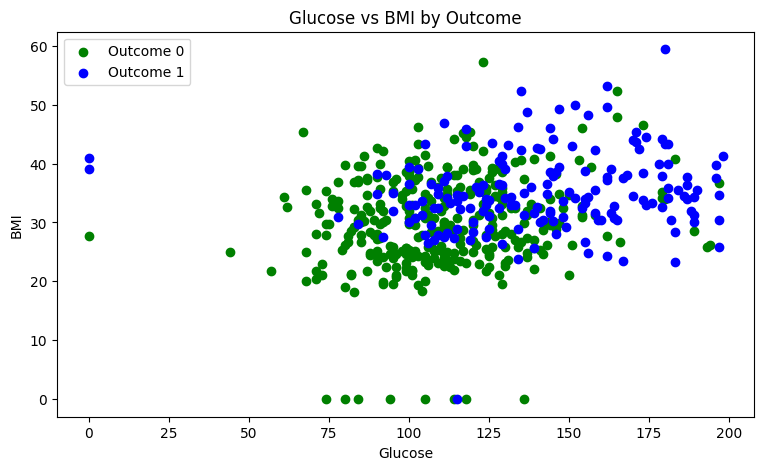

In [77]:
plt.figure(figsize=(9, 5))
plt.scatter(df[df['Outcome'] == 0]['Glucose'], df[df['Outcome'] == 0]['BMI'], color='green', label='Outcome 0')
plt.scatter(df[df['Outcome'] == 1]['Glucose'], df[df['Outcome'] == 1]['BMI'], color='blue', label='Outcome 1')
plt.title('Glucose vs BMI by Outcome')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.legend()
plt.show()

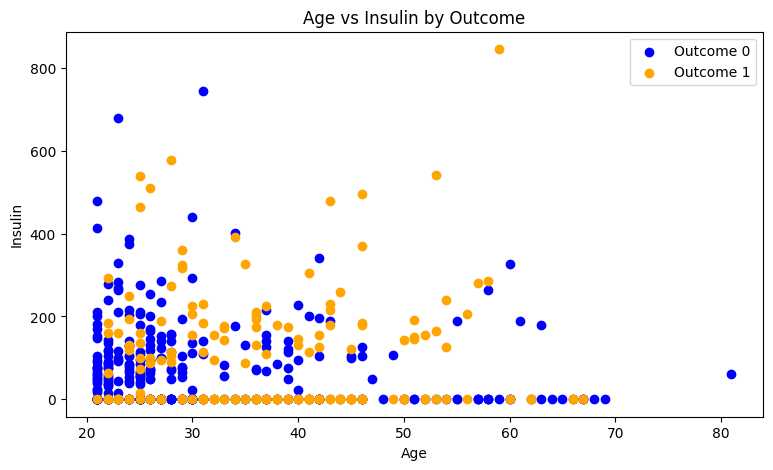

In [78]:
plt.figure(figsize=(9, 5))
plt.scatter(df[df['Outcome'] == 0]['Age'], df[df['Outcome'] == 0]['Insulin'], color='blue', label='Outcome 0')
plt.scatter(df[df['Outcome'] == 1]['Age'], df[df['Outcome'] == 1]['Insulin'], color='orange', label='Outcome 1')
plt.title('Age vs Insulin by Outcome')
plt.xlabel('Age')
plt.ylabel('Insulin')
plt.legend()
plt.show()

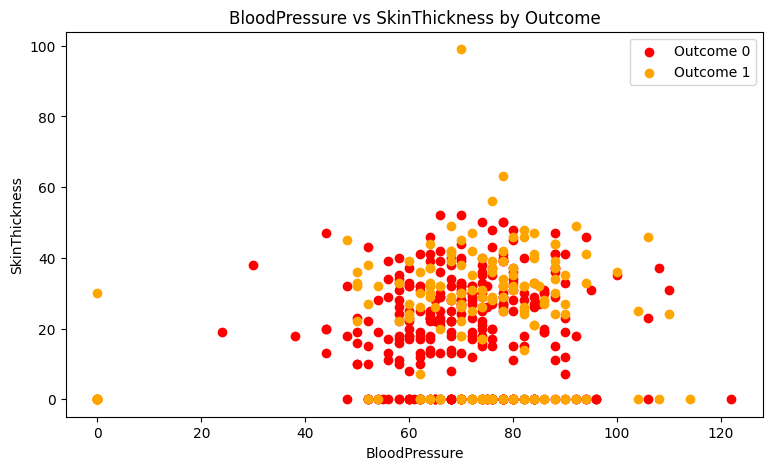

In [79]:
plt.figure(figsize=(9, 5))
plt.scatter(df[df['Outcome'] == 0]['BloodPressure'], df[df['Outcome'] == 0]['SkinThickness'], color='red', label='Outcome 0')
plt.scatter(df[df['Outcome'] == 1]['BloodPressure'], df[df['Outcome'] == 1]['SkinThickness'], color='orange', label='Outcome 1')
plt.title('BloodPressure vs SkinThickness by Outcome')
plt.xlabel('BloodPressure')
plt.ylabel('SkinThickness')
plt.legend()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_18936\4244198557.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome'] == 0]['Glucose'], df[df['Outcome'] == 1]['Glucose']], labels=['Outcome 0', 'Outcome 1'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_18936\4244198557.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome'] == 0]['BMI'], df[df['Outcome'] == 1]['BMI']], labels=['Outcome 0', 'Outcome 1'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_18936\4244198557.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['Outcome'] == 0]['Insulin'], df[df['O

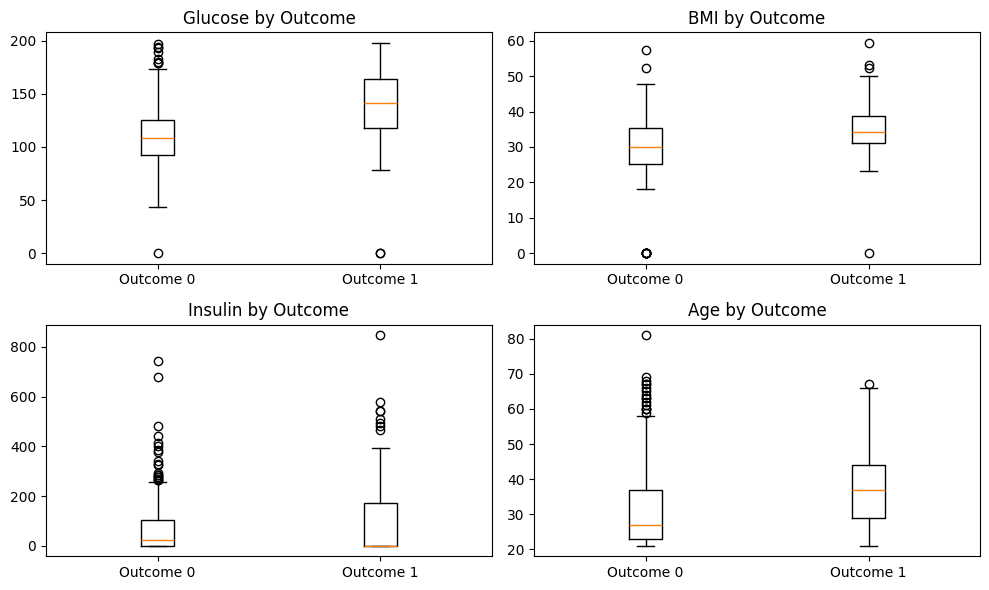

In [80]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.boxplot([df[df['Outcome'] == 0]['Glucose'], df[df['Outcome'] == 1]['Glucose']], labels=['Outcome 0', 'Outcome 1'])
plt.title('Glucose by Outcome')
plt.subplot(2, 2, 2)
plt.boxplot([df[df['Outcome'] == 0]['BMI'], df[df['Outcome'] == 1]['BMI']], labels=['Outcome 0', 'Outcome 1'])
plt.title('BMI by Outcome')
plt.subplot(2, 2, 3)
plt.boxplot([df[df['Outcome'] == 0]['Insulin'], df[df['Outcome'] == 1]['Insulin']], labels=['Outcome 0', 'Outcome 1'])
plt.title('Insulin by Outcome')
plt.subplot(2, 2, 4)
plt.boxplot([df[df['Outcome'] == 0]['Age'], df[df['Outcome'] == 1]['Age']], labels=['Outcome 0', 'Outcome 1'])
plt.title('Age by Outcome')
plt.tight_layout()
plt.show()

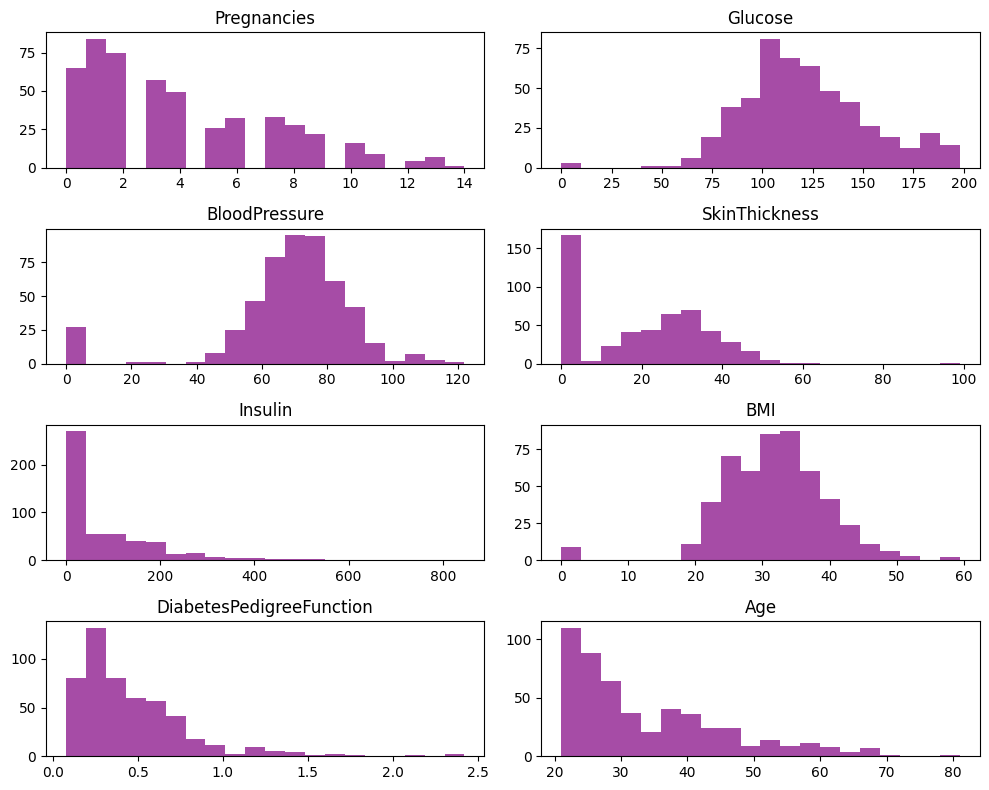

In [ ]:
plt.figure(figsize=(10, 8))
numeric_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
for i, feature in enumerate(numeric_features):
    plt.subplot(4, 2, i + 1)
    plt.hist(df[feature], bins=20, color='purple', alpha=0.7)
    plt.title(feature)
plt.tight_layout()

plt.show()

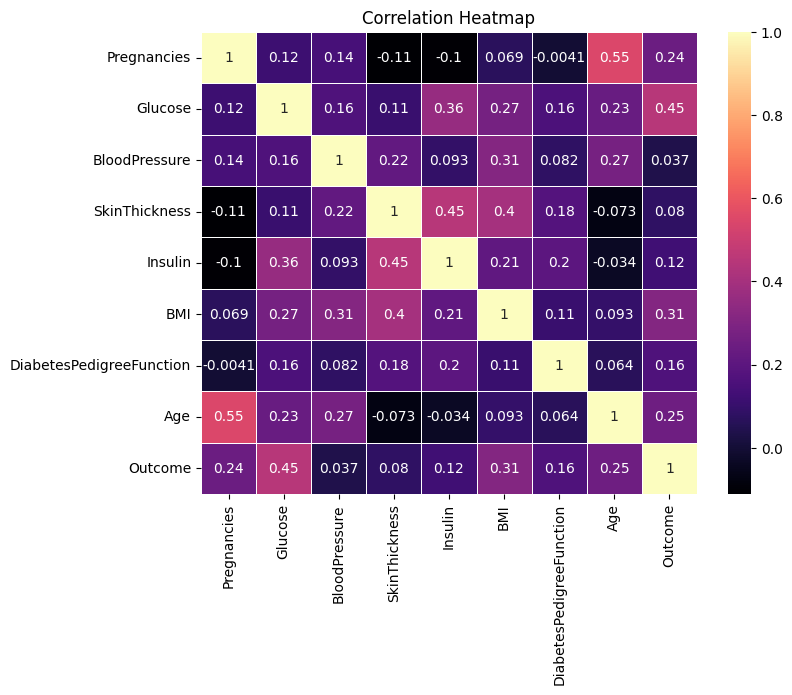

In [82]:
plt.figure(figsize=(8, 6))
corr_mat = df.corr()
sns.heatmap(corr_mat, annot=True, cmap='magma', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()